In [67]:
import matplotlib.pyplot as plt
import numpy as np
import cv2


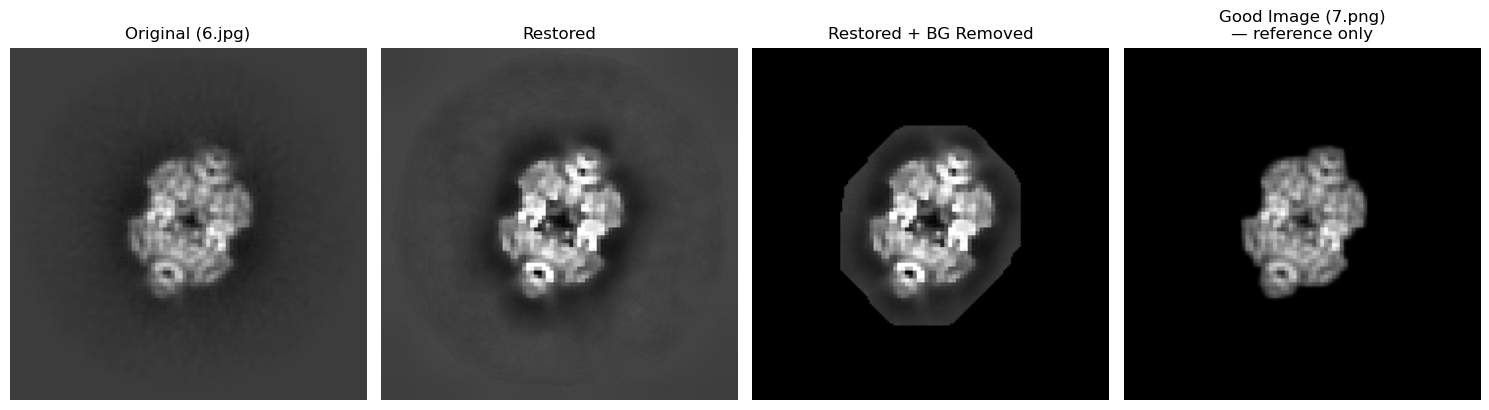

In [68]:
# Image paths
bad_restoration_image_path  = "/data/atran16/ProteinClassification_3D/3D_PDB_5013/testingDataFromProfessorSu/HYDROLASE/8dnm/6.jpg"
good_restoration_image_path = "/data/atran16/ProteinClassification_3D/3D_PDB_5013/testingDataFromProfessorSu/HYDROLASE/8dnm/7.png"

img_bad  = cv2.imread(bad_restoration_image_path)
img_good = cv2.imread(good_restoration_image_path)

img_bad_rgb  = cv2.cvtColor(img_bad,  cv2.COLOR_BGR2RGB)
img_good_rgb = cv2.cvtColor(img_good, cv2.COLOR_BGR2RGB)

########################################
# Step 1: Restoration
########################################
restored = cv2.bilateralFilter(img_bad, d=9, sigmaColor=75, sigmaSpace=75)

img_lab = cv2.cvtColor(restored, cv2.COLOR_BGR2LAB)
clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_lab[:, :, 0] = clahe.apply(img_lab[:, :, 0])
restored = cv2.cvtColor(img_lab, cv2.COLOR_LAB2BGR)

blur     = cv2.GaussianBlur(restored, (0, 0), sigmaX=2)
restored = cv2.addWeighted(restored, 1.5, blur, -0.5, 0)

########################################
# Step 2: Background removal (GrabCut on restored image)
########################################
mask     = np.zeros(restored.shape[:2], np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

h, w = restored.shape[:2]
rect = (10, 10, w-20, h-20)
cv2.grabCut(restored, mask, rect, bgdModel, fgdModel, 10, cv2.GC_INIT_WITH_RECT)

mask2  = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
mask2  = cv2.morphologyEx(mask2, cv2.MORPH_CLOSE, kernel, iterations=3)
mask2  = cv2.morphologyEx(mask2, cv2.MORPH_OPEN,  kernel, iterations=1)

final     = restored * mask2[:, :, np.newaxis]
final_rgb = cv2.cvtColor(final, cv2.COLOR_BGR2RGB)

########################################
# Show results
########################################
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_bad_rgb)
plt.title("Original (6.jpg)")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(cv2.cvtColor(restored, cv2.COLOR_BGR2RGB))
plt.title("Restored")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(final_rgb)
plt.title("Restored + BG Removed")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_good_rgb)
plt.title("Good Image (7.png)\n— reference only")
plt.axis('off')

plt.tight_layout()
plt.show()

In [69]:
import os

out_path = '/data/atran16/ProteinClassification_3D/visuallization/testVisuallizaion/restored_nobg.png'
cv2.imwrite(out_path, final)
print(f'Saved: {out_path}')

Saved: /data/atran16/ProteinClassification_3D/visuallization/testVisuallizaion/restored_nobg.png
